In [143]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial

In [148]:
def ncm(n, m):
    return int(factorial(n) / (factorial(m) * factorial(n-m)))

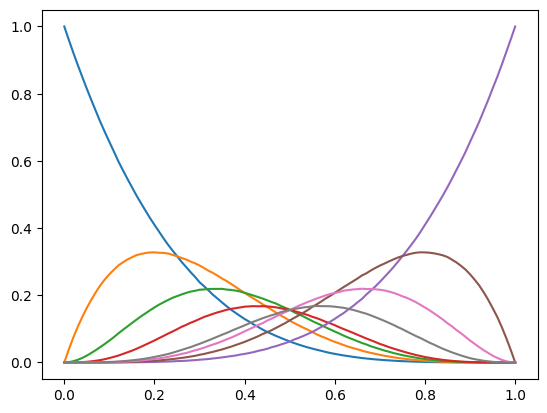

In [178]:
# Simulated probabilities
ntrials = 1000000

results_by_p = list()
outcomes = [f'{i}{j}' for i in 'LW' for j in range(4, 8)]

for p in np.linspace(0, 1, 101):
    w = np.random.random((ntrials, 7)) < p
    w_in = 8 - np.sum(np.cumsum(w, axis=1) >= 4, axis=1)
    l_in = 8 - np.sum(np.cumsum(~w, axis=1) >= 4, axis=1)
    result = np.column_stack((np.where(w_in < 8, 'W', 'L'),
                              np.where(w_in < 8, w_in, l_in)))\
                 .astype('<U1').reshape(-1).view('<U2')
    
    result_cts = dict(zip(*[i.tolist() 
                            for i in np.unique(result, return_counts=True)]))
    results_by_p += [[result_cts.get(r, 0) / ntrials for r in outcomes]]

results_by_p = dict(zip(outcomes, zip(*results_by_p)))

for k in outcomes:
    plt.plot(np.linspace(0, 1, 101), results_by_p[k])
plt.show()

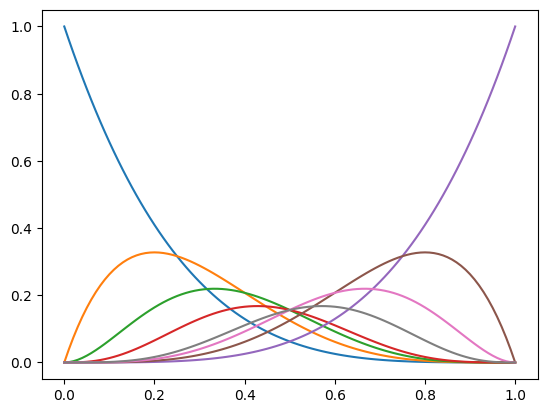

In [179]:
# Calculated probabilities
results_by_p_calc = dict()
p = np.linspace(0, 1, 101)

for i in range(4, 8):
    results_by_p_calc[f'W{i}'] = ((p ** 4) * ((1-p) ** (i-4)) * ncm(i-1, 3))
    results_by_p_calc[f'L{i}'] = (((1-p) ** 4) * (p ** (i-4)) * ncm(i-1, 3))

for k in outcomes:
    plt.plot(p, results_by_p_calc[k])
plt.show()